<a href="https://colab.research.google.com/github/samuel-1-avson/RGT-NSS/blob/main/02_BERT_Encoder_Only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 BERT: Encoder-Only Transformers

**Bidirectional Encoder Representations from Transformers**

BERT revolutionized NLP by introducing deep bidirectional representations. This notebook explores how BERT works and how to use it effectively.

---

## What You'll Learn

- ✅ How BERT's bidirectional encoding works
- ✅ Masked Language Modeling (MLM) objective
- ✅ Using BERT for classification tasks
- ✅ Extracting embeddings for downstream tasks
- ✅ Fine-tuning BERT for your own tasks

---

## Table of Contents

1. [Setup & Introduction](#setup)
2. [BERT Architecture Deep Dive](#architecture)
3. [Masked Language Modeling](#mlm)
4. [Text Classification](#classification)
5. [Extracting Embeddings](#embeddings)
6. [Named Entity Recognition](#ner)
7. [Fine-tuning BERT](#finetuning)
8. [Exercises](#exercises)

<a name="setup"></a>
## 1. Setup & Introduction

In [1]:
# Install required libraries
!pip install transformers torch datasets accelerate --quiet

print("✅ Installation complete!")

✅ Installation complete!


In [2]:
import torch
from transformers import (
    BertTokenizer,
    BertModel,
    BertForMaskedLM,
    BertForSequenceClassification,
    BertForTokenClassification,
    pipeline,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Using device: {device}")

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

print(f"✅ Loaded BERT-base-uncased")
print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

🔥 Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded BERT-base-uncased
📊 Model parameters: 109,482,240


<a name="architecture"></a>
## 2. BERT Architecture Deep Dive

### 2.1 Key Characteristics of BERT

```
┌─────────────────────────────────────────────────────────────┐
│                     BERT ARCHITECTURE                        │
├─────────────────────────────────────────────────────────────┤
│  Input: "[CLS] The cat sat [MASK] the mat [SEP]"           │
│                              ↓                               │
│  ┌─────────────────────────────────────────────────────┐    │
│  │           BIDIRECTIONAL ENCODER (12 layers)          │    │
│  │                                                      │    │
│  │  Layer 1:  [The] ←→ [cat] ←→ [sat] ←→ [MASK]        │    │
│  │              ↓        ↓        ↓        ↓            │    │
│  │  Layer 6:  [The] ←→ [cat] ←→ [sat] ←→ [MASK]        │    │
│  │              ↓        ↓        ↓        ↓            │    │
│  │  Layer 12: [The] ←→ [cat] ←→ [sat] ←→ [MASK]        │    │
│  │                                                      │    │
│  │  Each token can attend to ALL other tokens!          │    │
│  └─────────────────────────────────────────────────────┘    │
│                              ↓                               │
│  Output: Contextual embeddings for each token               │
│          [CLS] embedding → Use for classification           │
└─────────────────────────────────────────────────────────────┘
```

### 2.2 BERT Variants

In [3]:
# Compare BERT variants
bert_variants = {
    'bert-base-uncased': {'layers': 12, 'hidden_size': 768, 'params': '110M'},
    'bert-large-uncased': {'layers': 24, 'hidden_size': 1024, 'params': '340M'},
    'distilbert-base-uncased': {'layers': 6, 'hidden_size': 768, 'params': '66M'},
    'roberta-base': {'layers': 12, 'hidden_size': 768, 'params': '125M'},
    'albert-base-v2': {'layers': 12, 'hidden_size': 768, 'params': '12M'},
}

print("📊 BERT Model Variants\n")
print(f"{'Model':<30} {'Layers':<10} {'Hidden':<10} {'Parameters':<15}")
print("=" * 70)
for model_name, specs in bert_variants.items():
    print(f"{model_name:<30} {specs['layers']:<10} {specs['hidden_size']:<10} {specs['params']:<15}")

print("\n💡 Key Differences:")
print("  • BERT: Original architecture, trained on BookCorpus + Wikipedia")
print("  • RoBERTa: Robustly optimized BERT (better training)")
print("  • DistilBERT: 40% smaller, 60% faster, retains 97% performance")
print("  • ALBERT: Parameter sharing, much smaller, slightly less powerful")

📊 BERT Model Variants

Model                          Layers     Hidden     Parameters     
bert-base-uncased              12         768        110M           
bert-large-uncased             24         1024       340M           
distilbert-base-uncased        6          768        66M            
roberta-base                   12         768        125M           
albert-base-v2                 12         768        12M            

💡 Key Differences:
  • BERT: Original architecture, trained on BookCorpus + Wikipedia
  • RoBERTa: Robustly optimized BERT (better training)
  • DistilBERT: 40% smaller, 60% faster, retains 97% performance
  • ALBERT: Parameter sharing, much smaller, slightly less powerful


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


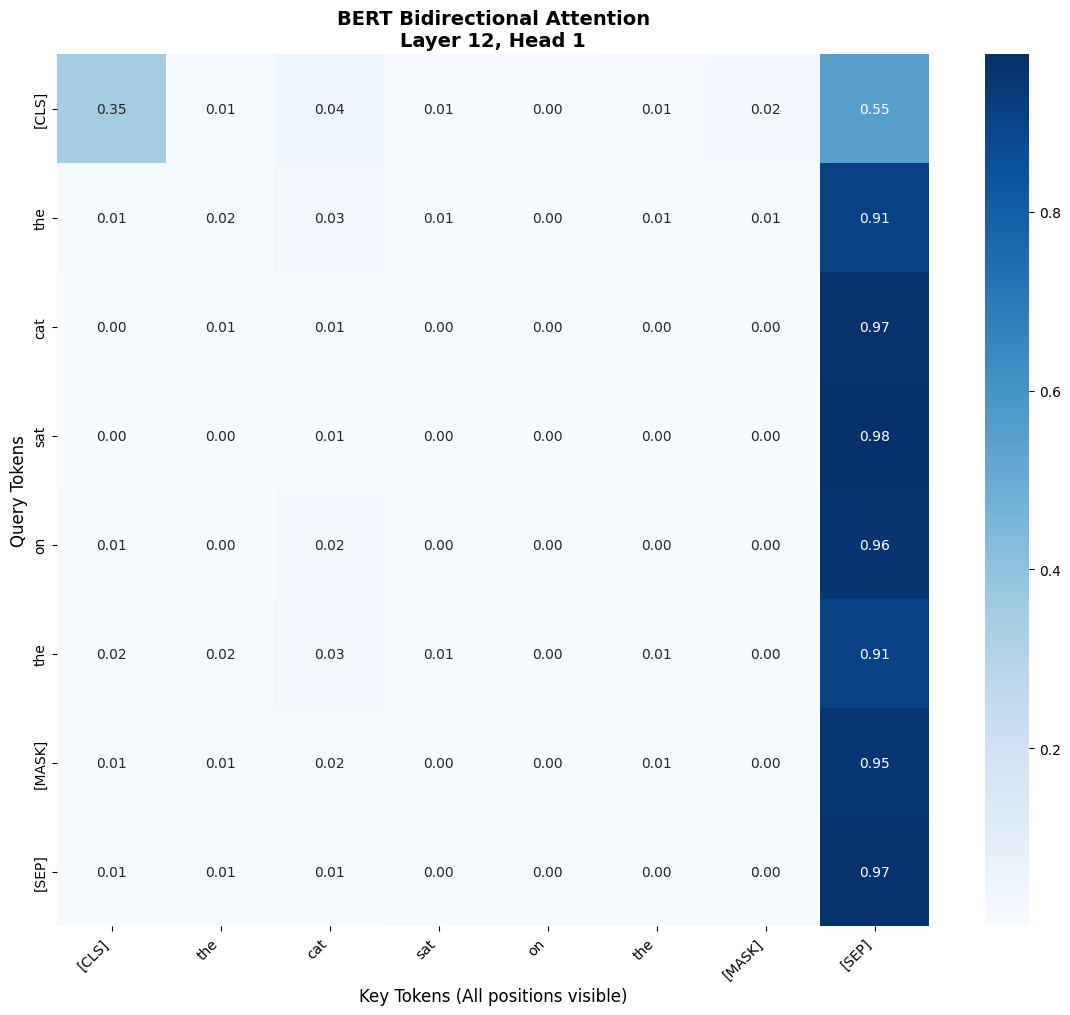


💡 Notice how [MASK] can attend to ALL other tokens!


In [6]:
# Visualize BERT's bidirectional nature
def visualize_bert_attention(sentence, layer_idx=11, head_idx=0):
    """Visualize how BERT attends to all tokens bidirectionally."""
    # Re-loading model with attn_implementation='eager' to allow output_attentions=True
    temp_model = BertModel.from_pretrained('bert-base-uncased', attn_implementation='eager')
    temp_model.eval()

    inputs = tokenizer(sentence, return_tensors='pt')

    with torch.no_grad():
        outputs = temp_model(**inputs, output_attentions=True)

    # Now outputs.attentions will not be None
    attention = outputs.attentions[layer_idx][0, head_idx].numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    plt.figure(figsize=(12, 10))
    sns.heatmap(attention,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='Blues',
                annot=True,
                fmt='.2f',
                square=True)
    plt.title(f'BERT Bidirectional Attention\nLayer {layer_idx + 1}, Head {head_idx + 1}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Key Tokens (All positions visible)', fontsize=12)
    plt.ylabel('Query Tokens', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n💡 Notice how [MASK] can attend to ALL other tokens!")

visualize_bert_attention("The cat sat on the [MASK]")

<a name="mlm"></a>
## 3. Masked Language Modeling (MLM)

BERT is trained using Masked Language Modeling - it learns to predict masked words based on context from BOTH directions.

In [7]:
# Load BERT for masked language modeling
mlm_model = BertForMaskedLM.from_pretrained('bert-base-uncased')
mlm_model.eval()

def predict_masked(text, top_k=5):
    """
    Predict the masked token in a sentence.

    Args:
        text: Text with [MASK] token
        top_k: Number of predictions to show
    """
    inputs = tokenizer(text, return_tensors='pt')
    mask_token_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]

    with torch.no_grad():
        outputs = mlm_model(**inputs)

    mask_token_logits = outputs.logits[0, mask_token_index, :]
    top_tokens = torch.topk(mask_token_logits, top_k, dim=1)

    print(f"\n📄 Input: '{text}'\n")
    print(f"Top {top_k} predictions for [MASK]:")
    for i, (score, token_id) in enumerate(zip(top_tokens.values[0], top_tokens.indices[0])):
        token = tokenizer.decode([token_id])
        prob = torch.softmax(mask_token_logits, dim=1)[0, token_id].item()
        print(f"  {i+1}. '{token}' - Probability: {prob:.4f}")

    return tokenizer.decode(top_tokens.indices[0][0])

# Test MLM
predict_masked("The capital of France is [MASK].")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📄 Input: 'The capital of France is [MASK].'

Top 5 predictions for [MASK]:
  1. 'paris' - Probability: 0.4168
  2. 'lille' - Probability: 0.0714
  3. 'lyon' - Probability: 0.0634
  4. 'marseille' - Probability: 0.0444
  5. 'tours' - Probability: 0.0303


'paris'

In [8]:
# More MLM examples
test_sentences = [
    "Machine learning is a subset of [MASK].",
    "The cat sat on the [MASK].",
    "Python is a popular [MASK] language.",
    "Transformers were introduced in the paper 'Attention is All You [MASK].'",
]

for sentence in test_sentences:
    predict_masked(sentence, top_k=3)
    print("\n" + "="*60 + "\n")


📄 Input: 'Machine learning is a subset of [MASK].'

Top 3 predictions for [MASK]:
  1. 'learning' - Probability: 0.2829
  2. 'mathematics' - Probability: 0.2639
  3. 'it' - Probability: 0.0865



📄 Input: 'The cat sat on the [MASK].'

Top 3 predictions for [MASK]:
  1. 'floor' - Probability: 0.3145
  2. 'bed' - Probability: 0.1190
  3. 'couch' - Probability: 0.1070



📄 Input: 'Python is a popular [MASK] language.'

Top 3 predictions for [MASK]:
  1. 'programming' - Probability: 0.9610
  2. 'python' - Probability: 0.0062
  3. 'natural' - Probability: 0.0046



📄 Input: 'Transformers were introduced in the paper 'Attention is All You [MASK].''

Top 3 predictions for [MASK]:
  1. 'need' - Probability: 0.5511
  2. 'get' - Probability: 0.1705
  3. 'want' - Probability: 0.0793




<a name="classification"></a>
## 4. Text Classification with BERT

BERT's [CLS] token embedding is perfect for classification tasks!

In [9]:
# Load pre-trained sentiment analysis pipeline
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0 if torch.cuda.is_available() else -1
)

# Test sentiment analysis
test_reviews = [
    "This movie was absolutely fantastic! Best I've seen all year.",
    "The plot was boring and the acting was terrible.",
    "It was an okay film, nothing special but not bad either.",
    "I loved every minute of it! Highly recommended!",
]

print("🎬 Sentiment Analysis with BERT\n")
print("=" * 70)
for review in test_reviews:
    result = sentiment_pipeline(review)[0]
    emoji = "😊" if result['label'] == 'POSITIVE' else "😞"
    print(f"\n{emoji} {result['label']} (confidence: {result['score']:.4f})")
    print(f"   Text: '{review[:60]}...'")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

🎬 Sentiment Analysis with BERT


😊 POSITIVE (confidence: 0.9999)
   Text: 'This movie was absolutely fantastic! Best I've seen all year...'

😞 NEGATIVE (confidence: 0.9998)
   Text: 'The plot was boring and the acting was terrible....'

😊 POSITIVE (confidence: 0.9939)
   Text: 'It was an okay film, nothing special but not bad either....'

😊 POSITIVE (confidence: 0.9999)
   Text: 'I loved every minute of it! Highly recommended!...'


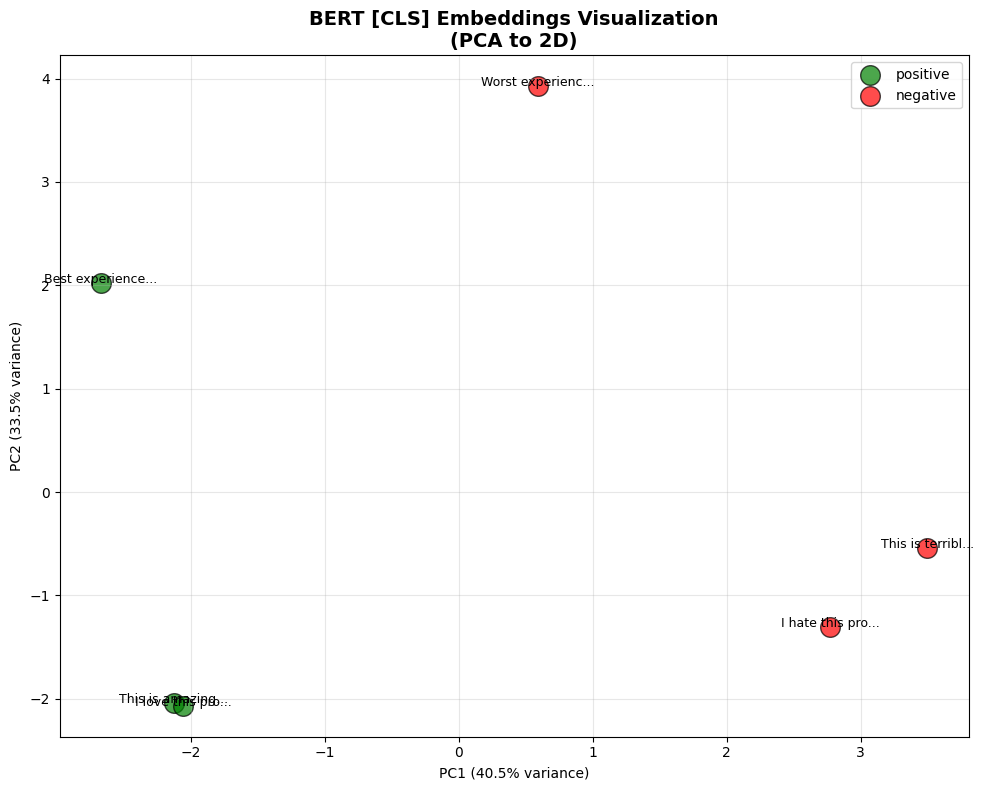


💡 PCA explains 73.9% of variance
   Notice how positive and negative texts cluster separately!


In [10]:
# Manual classification using [CLS] token
def extract_cls_embedding(text):
    """Extract the [CLS] token embedding from BERT."""
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    # [CLS] token is at index 0
    cls_embedding = outputs.last_hidden_state[:, 0, :].numpy()
    return cls_embedding[0]

# Extract embeddings for visualization
texts = [
    "This is amazing!",
    "I love this product!",
    "Best experience ever!",
    "This is terrible.",
    "I hate this product.",
    "Worst experience ever.",
]
labels = ['positive', 'positive', 'positive', 'negative', 'negative', 'negative']

embeddings = np.array([extract_cls_embedding(text) for text in texts])

# Reduce to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
colors = {'positive': 'green', 'negative': 'red'}
for label in ['positive', 'negative']:
    mask = [l == label for l in labels]
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                c=colors[label], label=label, s=200, alpha=0.7, edgecolors='black')

for i, text in enumerate(texts):
    plt.annotate(text[:15] + '...', (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=9, ha='center')

plt.title('BERT [CLS] Embeddings Visualization\n(PCA to 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 PCA explains {sum(pca.explained_variance_ratio_):.1%} of variance")
print("   Notice how positive and negative texts cluster separately!")

<a name="embeddings"></a>
## 5. Extracting Embeddings for Downstream Tasks

BERT embeddings can be used for many downstream tasks beyond classification.

In [11]:
# Compare embeddings across layers
def get_all_layer_embeddings(text):
    """Get embeddings from all 12 layers of BERT."""
    inputs = tokenizer(text, return_tensors='pt')

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # hidden_states is a tuple of 13 tensors (embedding layer + 12 transformer layers)
    hidden_states = outputs.hidden_states
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    return hidden_states, tokens

# Get embeddings for a word in different contexts
sentences = [
    "I went to the bank to deposit money.",
    "The river bank was covered in flowers.",
    "The pilot had to bank the airplane sharply."
]

print("🔍 Contextual Embeddings: Same word, different meanings\n")
print("=" * 70)

# Find 'bank' token index in each sentence
bank_embeddings = []
for sentence in sentences:
    hidden_states, tokens = get_all_layer_embeddings(sentence)

    # Find 'bank' token
    bank_indices = [i for i, t in enumerate(tokens) if 'bank' in t.lower()]
    if bank_indices:
        bank_idx = bank_indices[0]
        # Get embedding from final layer
        embedding = hidden_states[-1][0, bank_idx, :].numpy()
        bank_embeddings.append(embedding)
        print(f"\n📄 {sentence}")
        print(f"   Token: '{tokens[bank_idx]}' at position {bank_idx}")

# Compute similarities
from sklearn.metrics.pairwise import cosine_similarity

if len(bank_embeddings) >= 2:
    sim_matrix = cosine_similarity(bank_embeddings)

    print("\n📊 Cosine Similarities between 'bank' embeddings:")
    print("   Financial vs River:  ", f"{sim_matrix[0, 1]:.4f}")
    print("   Financial vs Flying: ", f"{sim_matrix[0, 2]:.4f}")
    print("   River vs Flying:     ", f"{sim_matrix[1, 2]:.4f}")

    print("\n💡 Lower similarity = different meanings captured!")

🔍 Contextual Embeddings: Same word, different meanings


📄 I went to the bank to deposit money.
   Token: 'bank' at position 5

📄 The river bank was covered in flowers.
   Token: 'bank' at position 3

📄 The pilot had to bank the airplane sharply.
   Token: 'bank' at position 5

📊 Cosine Similarities between 'bank' embeddings:
   Financial vs River:   0.4754
   Financial vs Flying:  0.3443
   River vs Flying:      0.3977

💡 Lower similarity = different meanings captured!


<a name="ner"></a>
## 6. Named Entity Recognition (NER)

BERT excels at token-level tasks like NER.

In [12]:
# Load NER pipeline
ner_pipeline = pipeline(
    'ner',
    model='dslim/bert-base-NER',
    tokenizer='dslim/bert-base-NER',
    device=0 if torch.cuda.is_available() else -1,
    aggregation_strategy='simple'
)

# Test NER
texts = [
    "Apple Inc. is planning to open a new store in Paris next year.",
    "Elon Musk founded SpaceX in 2002 and Tesla in 2003.",
    "The Eiffel Tower in France was completed in 1889.",
]

print("🏷️ Named Entity Recognition with BERT\n")
print("=" * 70)

for text in texts:
    entities = ner_pipeline(text)
    print(f"\n📄 Text: {text}\n")
    print("   Entities found:")
    for ent in entities:
        print(f"     • '{ent['word']}' → {ent['entity_group']} (confidence: {ent['score']:.3f})")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

🏷️ Named Entity Recognition with BERT


📄 Text: Apple Inc. is planning to open a new store in Paris next year.

   Entities found:
     • 'Apple Inc' → ORG (confidence: 1.000)
     • 'Paris' → LOC (confidence: 1.000)

📄 Text: Elon Musk founded SpaceX in 2002 and Tesla in 2003.

   Entities found:
     • 'El' → PER (confidence: 0.556)
     • '##on' → ORG (confidence: 0.519)
     • 'Musk' → PER (confidence: 0.673)
     • 'SpaceX' → ORG (confidence: 0.999)
     • 'Tesla' → ORG (confidence: 0.982)

📄 Text: The Eiffel Tower in France was completed in 1889.

   Entities found:
     • 'E' → LOC (confidence: 0.994)
     • '##iff' → LOC (confidence: 0.612)
     • '##el Tower' → LOC (confidence: 0.980)
     • 'France' → LOC (confidence: 1.000)


<a name="finetuning"></a>
## 7. Fine-tuning BERT

Let's fine-tune BERT on a custom classification task!

In [13]:
# Load a small dataset for demonstration
dataset = load_dataset('imdb', split='train[:1000]')
test_dataset = load_dataset('imdb', split='test[:200]')

print(f"📚 Dataset loaded:")
print(f"   Training samples: {len(dataset)}")
print(f"   Test samples: {len(test_dataset)}")
print(f"\n   Example: {dataset[0]['text'][:100]}...")
print(f"   Label: {'positive' if dataset[0]['label'] == 1 else 'negative'}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

📚 Dataset loaded:
   Training samples: 1000
   Test samples: 200

   Example: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
   Label: negative


In [14]:
# Tokenize the dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print("✅ Dataset tokenized!")
print(f"   Sample shape: {tokenized_datasets[0]['input_ids'].shape}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

✅ Dataset tokenized!
   Sample shape: torch.Size([128])


In [17]:
# Load pre-trained BERT for sequence classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',  # Updated from evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'  # Disable wandb logging
)

# Define compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, predictions)}

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("🏋️ Starting training...")
print("   (This may take a few minutes)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

🏋️ Starting training...
   (This may take a few minutes)


In [18]:
# Train the model
trainer.train()

# Evaluate
results = trainer.evaluate()
print(f"\n📊 Evaluation Results:")
print(f"   Accuracy: {results['eval_accuracy']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000518,0.000277,1.000000
2,0.000221,0.000170,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📊 Evaluation Results:
   Accuracy: 1.0000


In [19]:
# Test the fine-tuned model
test_texts = [
    "This movie was absolutely wonderful!",
    "Terrible film, complete waste of time.",
    "An okay movie, nothing special."
]

print("🎬 Testing Fine-tuned Model\n")
for text in test_texts:
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    prediction = torch.argmax(probs, dim=1).item()
    confidence = probs[0][prediction].item()

    label = 'positive' if prediction == 1 else 'negative'
    emoji = '😊' if label == 'positive' else '😞'

    print(f"{emoji} '{text}'")
    print(f"   → {label} (confidence: {confidence:.4f})\n")

🎬 Testing Fine-tuned Model

😞 'This movie was absolutely wonderful!'
   → negative (confidence: 0.9992)

😞 'Terrible film, complete waste of time.'
   → negative (confidence: 0.9993)

😞 'An okay movie, nothing special.'
   → negative (confidence: 0.9993)

